# VAE Pretraining
Here we will pretrain a VAE using an architecture very similar to the Gómez-Bombarelli / `molecular-vae` style (conv encoder + GRU decoder). The key change is that we will now use SELFIES instead of SMILES.

We will train 3 models from different data sources: ChemBL, Zinc, and ChemBL + Zinc.


### Imports and config

In [11]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120  # max SELFIES token length before EOS
VAL_FRAC = 0.10
TEST_FRAC = 0.10

LATENT_DIM = 292
EPOCHS = 20
BATCH_SIZE = 128
LR = 1e-3
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.1

USE_WANDB = False
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "pretrain-chembl-zinc-seqconv"

CHECKPOINT_DIR = Path("artifacts") / "pretraining_checkpoints"
CHECKPOINT_STEM = "paper_like_selfies_chembl_zinc_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda devices:", torch.cuda.device_count())
print(
    "current device:",
    torch.cuda.current_device() if torch.cuda.is_available() else None,
)
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

torch: 2.5.1+cu121
cuda available: True
cuda devices: 1
current device: 0
device name: NVIDIA GeForce RTX 2070
device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL and Zinc datasets

In [5]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

print(f"ChemBL unique SMILES: {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:   {len(zinc_smiles):,}")
print(f"Combined unique SMILES for pretraining: {len(pretrain_smiles):,}")

ChemBL unique SMILES: 23,871
Zinc unique SMILES:   249,455
Combined unique SMILES for pretraining: 273,321


### Convert to SELFIES and create the combined pretraining split

In [6]:
def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(
    items: list[str], val_frac: float, test_frac: float, seed: int
) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test : n_test + n_val]
    train_idx = idx[n_test + n_val :]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


pretrain_selfies, pretrain_failed = smiles_to_selfies(pretrain_smiles)
pretrain_selfies = filter_selfies_len(pretrain_selfies, max_len=MAX_LEN)
train_selfies, val_selfies, test_selfies = split_list(
    pretrain_selfies, VAL_FRAC, TEST_FRAC, seed=SEED
)

print(f"SELFIES conversion failures: {pretrain_failed}")
print(
    f"filtered combined split sizes: train={len(train_selfies):,}, "
    f"val={len(val_selfies):,}, test={len(test_selfies):,}"
)

SELFIES conversion failures: 0
filtered combined split sizes: train=218,336, val=27,292, test=27,292


### Tokenization and encoding

In [7]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"


def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


train_tokens = [tokenize_selfies(s) for s in train_selfies]
vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})
ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if SEQ_LEN < 29:
    raise ValueError("Sequence length is too small for conv kernels (9, 9, 11).")


def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, : len(ids)] = ids
    return out


train_x = encode_list(train_selfies)
val_x = encode_list(val_selfies)
test_x = encode_list(test_selfies)

print(f"train={train_x.shape}, val={val_x.shape}, test={test_x.shape}")
print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")

train=(218336, 121), val=(27292, 121), test=(27292, 121)
VOCAB_SIZE=115, SEQ_LEN=121


### SELFIES VAE

In [8]:
class TokenDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(x).long()

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx]


class PaperLikeSelfiesVAE(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # Conv1d expects [batch, channels, length], so we encode one-hot SELFIES as [B, vocab, seq].
        self.conv_1 = nn.Conv1d(in_channels=vocab_size, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(
            input_size=292, hidden_size=501, num_layers=3, batch_first=True
        )
        self.linear_4 = nn.Linear(501, vocab_size)

    def encoder(self, x_onehot: torch.Tensor):
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z: torch.Tensor):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        logits = self.linear_4(out)
        return logits

    def forward(self, x_onehot: torch.Tensor):
        mean, logvar = self.encoder(x_onehot)
        z = self.sampling(mean, logvar)
        logits = self.decode(z)
        return logits, mean, logvar


def ids_to_onehot(x_ids: torch.Tensor, vocab_size: int):
    return F.one_hot(x_ids, num_classes=vocab_size).float().transpose(1, 2).contiguous()


def vae_loss(
    logits: torch.Tensor,
    x_ids: torch.Tensor,
    mean: torch.Tensor,
    logvar: torch.Tensor,
    *,
    pad_idx: int,
    beta: float = 1.0,
    free_bits_nats: float = 0.0,
):
    vocab_size = logits.size(-1)
    recon_sum = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        x_ids.reshape(-1),
        ignore_index=pad_idx,
        reduction="sum",
    )

    kl_per_dim = -0.5 * (1 + logvar - mean.pow(2) - logvar.exp())
    if free_bits_nats and free_bits_nats > 0:
        kl_per_dim = torch.clamp(kl_per_dim, min=float(free_bits_nats))
    kl_sum = kl_per_dim.sum()

    n_nonpad = (x_ids != pad_idx).sum().clamp(min=1)
    total = recon_sum + beta * kl_sum
    return total, recon_sum, kl_sum, n_nonpad


def kl_beta(epoch: int, anneal_epochs: int) -> float:
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))

### Training and evaluation helpers

In [9]:
def make_loader(x: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(TokenDataset(x), batch_size=batch_size, shuffle=shuffle)


def init_wandb(*, run_name: str | None = None, epochs: int | None = None):
    if not USE_WANDB:
        return None
    if wandb is None:
        raise ImportError("wandb is not installed. Install it or set USE_WANDB=False.")

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "epochs": epochs if epochs is not None else EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "free_bits_nats": FREE_BITS_NATS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(
    model: nn.Module, loader: DataLoader, *, optimizer=None, beta: float = 1.0
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_sum = 0.0
    recon_sum = 0.0
    kl_sum = 0.0
    n_samples = 0
    n_nonpad = 0
    n_correct = 0

    for x_ids in loader:
        x_ids = x_ids.to(device)
        x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits, mean, logvar = model(x_onehot)
            total, recon, kl, nonpad = vae_loss(
                logits,
                x_ids,
                mean,
                logvar,
                pad_idx=PAD_IDX,
                beta=beta,
                free_bits_nats=FREE_BITS_NATS,
            )
            if is_train:
                total.backward()
                optimizer.step()

        mask = x_ids != PAD_IDX
        preds = logits.argmax(dim=-1)

        total_sum += total.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n_samples += x_ids.size(0)
        n_nonpad += int(nonpad.item())
        n_correct += ((preds == x_ids) & mask).sum().item()

    return {
        "total": total_sum / max(n_samples, 1),
        "recon_per_token": recon_sum / max(n_nonpad, 1),
        "kl": kl_sum / max(n_samples, 1),
        "token_acc": n_correct / max(n_nonpad, 1),
    }


def evaluate(model: nn.Module, x: np.ndarray, *, beta: float):
    loader = make_loader(x, batch_size=BATCH_SIZE, shuffle=False)
    return run_epoch(model, loader, optimizer=None, beta=beta)


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": (
            optimizer.state_dict() if optimizer is not None else None
        ),
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        optimizer=optimizer,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)


def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    history: dict | None = None,
    start_epoch: int = 0,
    num_epochs: int = EPOCHS,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
):
    if model is None:
        model = PaperLikeSelfiesVAE(
            vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM
        ).to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_loader = make_loader(train_x, batch_size=BATCH_SIZE, shuffle=True)

    if history is None:
        history = {
            "beta": [],
            "train_total": [],
            "val_total": [],
            "train_recon_per_token": [],
            "val_recon_per_token": [],
            "train_kl": [],
            "val_kl": [],
            "train_token_acc": [],
            "val_token_acc": [],
        }
    else:
        for key in [
            "beta",
            "train_total",
            "val_total",
            "train_recon_per_token",
            "val_recon_per_token",
            "train_kl",
            "val_kl",
            "train_token_acc",
            "val_token_acc",
        ]:
            history.setdefault(key, [])

    if history["val_total"]:
        best_idx = int(np.argmin(history["val_total"]))
        best_epoch = best_idx + 1
        best_val_total = float(history["val_total"][best_idx])
    else:
        best_epoch = None
        best_val_total = float("inf")

    if checkpoint_dir is not None and checkpoint_stem is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(run_name=wandb_run_name, epochs=num_epochs)

    for rel_ep in range(1, num_epochs + 1):
        ep = start_epoch + rel_ep
        beta = kl_beta(ep, KL_ANNEAL_EPOCHS)
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, beta=beta)
        val_metrics = evaluate(model, val_x, beta=beta)

        history["beta"].append(beta)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_kl"].append(train_metrics["kl"])
        history["val_kl"].append(val_metrics["kl"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])

        is_best = val_metrics["total"] < best_val_total
        if is_best:
            best_val_total = float(val_metrics["total"])
            best_epoch = ep

        print(
            f"epoch {ep:03d} | beta={beta:.2f} | "
            f"train total={train_metrics['total']:.4f} | val total={val_metrics['total']:.4f} | "
            f"train token acc={train_metrics['token_acc']:.4f} | val token acc={val_metrics['token_acc']:.4f}"
            + (" | new best" if is_best else "")
        )

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model,
                history,
                save_dir=checkpoint_dir,
                checkpoint_stem=checkpoint_stem,
                epoch=ep,
                best_epoch=best_epoch,
                best_val_total=best_val_total,
                optimizer=optimizer,
                is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints,
            )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "epoch": ep,
                    "beta": beta,
                    "train/total": train_metrics["total"],
                    "val/total": val_metrics["total"],
                    "train/recon_per_token": train_metrics["recon_per_token"],
                    "val/recon_per_token": val_metrics["recon_per_token"],
                    "train/kl": train_metrics["kl"],
                    "val/kl": val_metrics["kl"],
                    "train/token_acc": train_metrics["token_acc"],
                    "val/token_acc": val_metrics["token_acc"],
                    "best/val_total": best_val_total,
                    "best/epoch": best_epoch,
                },
                step=ep,
            )

    if wandb_run is not None:
        wandb_run.finish()

    checkpoint_info = {
        "best_epoch": best_epoch,
        "best_val_total": best_val_total,
        "last_epoch": start_epoch + num_epochs,
    }
    return model, history, checkpoint_info

### Train the ChemBL + Zinc pretraining model

In [ ]:
save_dir = CHECKPOINT_DIR
save_dir.mkdir(parents=True, exist_ok=True)

print("Training on the combined ChemBL + Zinc pretraining set...")
model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    checkpoint_dir=save_dir,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

# Keep the legacy single-checkpoint path for backwards compatibility.
ckpt_path = save_dir / f"{CHECKPOINT_STEM}.pt"
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=len(history["beta"]),
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=None,
        test_metrics=test_metrics,
    ),
    ckpt_path,
)

results_df = pd.DataFrame(
    [
        {
            "run_name": "chembl_zinc",
            "n_train": len(train_x),
            "n_val": len(val_x),
            "n_test": len(test_x),
            "final_train_total": history["train_total"][-1],
            "final_val_total": history["val_total"][-1],
            "final_train_token_acc": history["train_token_acc"][-1],
            "final_val_token_acc": history["val_token_acc"][-1],
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_recon_per_token": test_metrics["recon_per_token"],
            "test_kl": test_metrics["kl"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(save_dir / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(save_dir / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_compat": str(ckpt_path),
        }
    ]
)
results_df

### Plot training curves

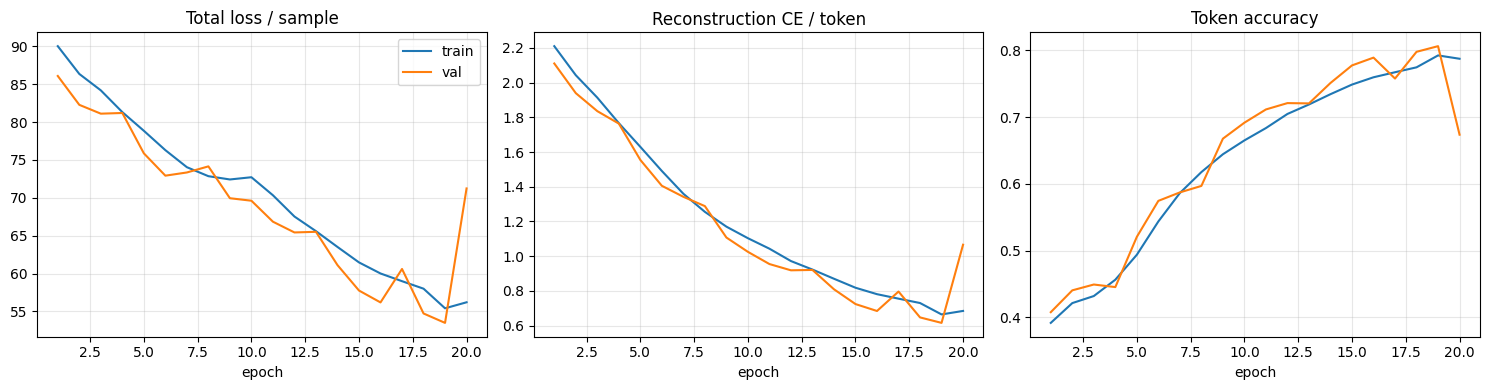

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = np.arange(1, len(history["train_total"]) + 1)

axes[0].plot(epochs, history["train_total"], label="train")
axes[0].plot(epochs, history["val_total"], label="val")
axes[0].set_title("Total loss / sample")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_recon_per_token"], label="train")
axes[1].plot(epochs, history["val_recon_per_token"], label="val")
axes[1].set_title("Reconstruction CE / token")
axes[1].set_xlabel("epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["train_token_acc"], label="train")
axes[2].plot(epochs, history["val_token_acc"], label="val")
axes[2].set_title("Token accuracy")
axes[2].set_xlabel("epoch")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Quick reconstruction check

In [11]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)

[0] exact=False
orig: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C@@H1][Branch1][Ring2][C][Ring1][#Branch1][NH2+1][Ring1][=Branch1]
pred: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C][Branch1][C][C][Ring1][Branch1][C][Ring1][Ring1]

[1] exact=False
orig: [C][C][C@@H1][Branch2][Ring1][=Branch1][O][C][=Branch1][C][=O][C][=C][C][=C][C][Branch1][#Branch1][N][C][Branch1][C][C][=O][=C][Ring1][#Branch2][C][=Branch1][C][=O][N][C][C][=C][Branch1][C][C][O][N][=Ring1][=Branch1]
pred: [C][C][C@H1][Branch2][Ring1][#Branch1][C][C][=Branch1][C][=O][C][=C][C][C][=C][Ring1][=Branch1][C][C][Branch1][C][C][C][C][Ring1][Branch1][C][=Branch1][C][=O][N][C][C][=N][C][Branch1][C][C][C][Ring1][Ring1]

[2] exact=False
orig: [Cl][C][C@H1][C][C][C][O][C@H1][Ring1][=Branch1][C][=C][C][=C][Branch1][C][Cl][S][Ring1][=Branch1]
pred: [C][C][C@H1][C][C][C][C][C@H1][Ring1][Branch1][C][=C][C][=C][Branch1][C][Cl][O][Ring1][#Branc

### Notes for later tox21 post-training
This notebook now saves a new sequence-convolution checkpoint. Update the model definition in the post-training notebook before loading it, or keep using the older checkpoint if you want the old architecture.


### Temporary: continue training for +10 epochs from the latest checkpoint


In [14]:
EXTRA_EPOCHS = 10

resume_last_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"
legacy_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}.pt"
resume_path = resume_last_path if resume_last_path.exists() else legacy_path

if not resume_path.exists():
    raise FileNotFoundError(
        f"Could not find a checkpoint to resume from. Checked: {resume_last_path} and {legacy_path}"
    )

print("Resuming from:", resume_path)
resume_bundle = torch.load(resume_path, map_location=device)

model_resume = PaperLikeSelfiesVAE(
    vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM
).to(device)
model_resume.load_state_dict(resume_bundle["model_state_dict"])

optimizer_resume = torch.optim.Adam(model_resume.parameters(), lr=LR)
if resume_bundle.get("optimizer_state_dict") is not None:
    optimizer_resume.load_state_dict(resume_bundle["optimizer_state_dict"])
else:
    print("No optimizer state found in checkpoint; using fresh Adam optimizer.")

history_resume = resume_bundle.get("history")
if history_resume is not None and "beta" in history_resume:
    start_epoch = int(resume_bundle.get("epoch", len(history_resume["beta"])))
else:
    history_resume = None
    start_epoch = int(resume_bundle.get("epoch", 0))

print(
    f"Loaded start_epoch={start_epoch}. Will train through epoch {start_epoch + EXTRA_EPOCHS}."
)

Resuming from: artifacts/pretraining_checkpoints/paper_like_selfies_chembl_zinc_seqconv_ce.pt
No optimizer state found in checkpoint; using fresh Adam optimizer.
Loaded start_epoch=20. Will train through epoch 30.


In [18]:
continued_run_name = f"{WANDB_RUN_NAME}-resume-{start_epoch + EXTRA_EPOCHS}"

model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    model=model_resume,
    optimizer=optimizer_resume,
    history=history_resume,
    start_epoch=start_epoch,
    num_epochs=EXTRA_EPOCHS,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name=continued_run_name,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

final_epoch = len(history["beta"])
continuation_ckpt_path = (
    CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_continued_to_epoch_{final_epoch:03d}.pt"
)
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    continuation_ckpt_path,
)

# Refresh *_last with test metrics from the continued model.
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt",
)

pd.DataFrame(
    [
        {
            "start_epoch": start_epoch,
            "end_epoch": final_epoch,
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_continued": str(continuation_ckpt_path),
        }
    ]
)

epoch 021 | beta=1.00 | train total=56.0645 | val total=77.4692 | train token acc=0.7892 | val token acc=0.6110
epoch 022 | beta=1.00 | train total=53.1101 | val total=50.7707 | train token acc=0.8100 | val token acc=0.8273 | new best
epoch 023 | beta=1.00 | train total=51.2929 | val total=55.4964 | train token acc=0.8231 | val token acc=0.7942
epoch 024 | beta=1.00 | train total=60.8528 | val total=55.0665 | train token acc=0.7556 | val token acc=0.7953
epoch 025 | beta=1.00 | train total=56.4252 | val total=50.6999 | train token acc=0.7876 | val token acc=0.8292 | new best
epoch 026 | beta=1.00 | train total=50.3565 | val total=48.3512 | train token acc=0.8310 | val token acc=0.8460 | new best
epoch 027 | beta=1.00 | train total=56.6366 | val total=48.9069 | train token acc=0.7875 | val token acc=0.8425
epoch 028 | beta=1.00 | train total=57.1128 | val total=48.1932 | train token acc=0.7827 | val token acc=0.8479 | new best
epoch 029 | beta=1.00 | train total=58.0130 | val total=50.0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/epoch,▁▃▃▃▅▅▅▇▇█
best/val_total,█▆▆▆▆▃▃▃▃▁
beta,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train/kl,▇██▆▄▅▃▃▂▁
train/recon_per_token,▅▄▃█▆▂▆▆▆▁
train/token_acc,▄▅▆▁▃▇▃▃▃█
train/total,▅▄▃█▆▂▆▆▆▁
val/kl,█▅▆▂▃▄▄▃▁▂
val/recon_per_token,█▂▃▃▂▂▂▂▂▁
+2,...


,start_epoch,end_epoch,best_epoch,best_val_total,test_total,test_token_acc,checkpoint_best,checkpoint_last,checkpoint_continued
0,20,30,30,45.675472,45.803002,0.867677,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...


# Test on Tox 21 test set!

## XGBoost on tox21 using VAE latent features
Use the best pretrained VAE checkpoint to extract latent means (`mu`) from tox21 SMILES, then train one XGBoost classifier per tox21 task.

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

TOX21_TRAIN_PATH = Path("data") / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = Path("data") / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"

best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(
    vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM
).to(device)
model_best.load_state_dict(bundle["model_state_dict"])
model_best.eval()

TASKS = [
    c
    for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns
    if c.startswith("NR-") or c.startswith("SR-")
]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[: len(ids)] = ids
    return arr


def build_latent_split(csv_path: Path, task_cols: list[str], batch_size: int = 512):
    df = (
        pd.read_csv(csv_path).dropna(subset=["canonical_smiles"]).reset_index(drop=True)
    )
    y_all = df[task_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

    x_ids_list, y_kept = [], []
    failed = 0
    for smi, y in zip(df["canonical_smiles"].astype(str).tolist(), y_all):
        ids = _smiles_to_ids_for_vocab(smi)
        if ids is None:
            failed += 1
            continue
        x_ids_list.append(ids)
        y_kept.append(y)

    x_ids = np.stack(x_ids_list)
    y = np.stack(y_kept)

    z_chunks = []
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            xb = torch.from_numpy(x_ids[i : i + batch_size]).long().to(device)
            x_onehot_seq_vocab = F.one_hot(xb, num_classes=VOCAB_SIZE).float()
            x_onehot_vocab_seq = x_onehot_seq_vocab.transpose(1, 2).contiguous()
            mean, _ = model_best.encoder(x_onehot_vocab_seq)
            z_chunks.append(mean.cpu().numpy())

    z = np.vstack(z_chunks)
    return z, y, failed


Z_train, Y_train, fail_train = build_latent_split(TOX21_TRAIN_PATH, TASKS)
Z_val, Y_val, fail_val = build_latent_split(TOX21_VAL_PATH, TASKS)
Z_test, Y_test, fail_test = build_latent_split(TOX21_TEST_PATH, TASKS)

print("Loaded latent feature matrices:")
print(f"train: Z={Z_train.shape}, Y={Y_train.shape}, skipped={fail_train}")
print(f"val  : Z={Z_val.shape}, Y={Y_val.shape}, skipped={fail_val}")
print(f"test : Z={Z_test.shape}, Y={Y_test.shape}, skipped={fail_test}")

Loaded latent feature matrices:
train: Z=(6237, 292), Y=(6237, 12), skipped=21
val  : Z=(770, 292), Y=(770, 12), skipped=12
test : Z=(765, 292), Y=(765, 12), skipped=18


In [22]:
task_rows = []
roc_curves = {}
pr_curves = {}

for j, task in enumerate(TASKS):
    ytr, yv, yt = Y_train[:, j], Y_val[:, j], Y_test[:, j]

    mtr = np.isin(ytr, [0, 1])
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Need both classes for training and evaluation
    if len(np.unique(ytr[mtr])) < 2 or len(np.unique(yt[mt])) < 2:
        continue

    clf = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    clf.fit(Z_train[mtr], ytr[mtr], eval_set=[(Z_val[mv], yv[mv])], verbose=False)

    p_val = clf.predict_proba(Z_val[mv])[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t = max(
        thresholds,
        key=lambda t: f1_score(yv[mv], (p_val >= t).astype(int), zero_division=0),
    )

    p_test = clf.predict_proba(Z_test[mt])[:, 1]
    y_true = yt[mt].astype(int)
    y_hat = (p_test >= best_t).astype(int)

    auroc = roc_auc_score(y_true, p_test)
    auprc = average_precision_score(y_true, p_test)

    task_rows.append(
        {
            "task": task,
            "n_test": int(mt.sum()),
            "threshold": float(best_t),
            "AUROC": float(auroc),
            "AUPRC": float(auprc),
            "Accuracy": float(accuracy_score(y_true, y_hat)),
            "F1": float(f1_score(y_true, y_hat, zero_division=0)),
            "Precision": float(precision_score(y_true, y_hat, zero_division=0)),
            "Recall": float(recall_score(y_true, y_hat, zero_division=0)),
        }
    )

    fpr, tpr, _ = roc_curve(y_true, p_test)
    prec, rec, _ = precision_recall_curve(y_true, p_test)
    roc_curves[task] = (fpr, tpr, auroc)
    pr_curves[task] = (rec, prec, auprc, float(y_true.mean()))

metrics_df = (
    pd.DataFrame(task_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
)
metrics_df

,task,n_test,threshold,AUROC,AUPRC,Accuracy,F1,Precision,Recall
0,NR-AR-LBD,765,0.25,0.756667,0.292186,0.973856,0.333333,0.454545,0.263158
1,SR-ATAD5,765,0.05,0.728001,0.099894,0.942484,0.083333,0.125000,0.062500
2,NR-AhR,765,0.10,0.704291,0.263756,0.798693,0.324561,0.270073,0.406593
3,NR-AR,765,0.40,0.694919,0.237223,0.964706,0.307692,0.428571,0.240000
4,NR-ER-LBD,765,0.20,0.671915,0.123758,0.966013,0.071429,0.142857,0.047619
5,SR-MMP,765,0.10,0.669690,0.206388,0.720261,0.272109,0.200000,0.425532
6,NR-ER,765,0.25,0.624124,0.163291,0.898039,0.113636,0.250000,0.073529
7,SR-p53,765,0.05,0.620735,0.160594,0.877124,0.203390,0.230769,0.181818
8,NR-Aromatase,765,0.05,0.601832,0.092292,0.918954,0.060606,0.100000,0.043478
9,NR-PPAR-gamma,765,0.05,0.566316,0.046606,0.969935,0.000000,0.000000,0.000000


In [23]:
print("Macro average metrics:")
metrics_df[["AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]].mean().to_frame(
    "macro_mean"
).T

Macro average metrics:


,AUROC,AUPRC,Accuracy,F1,Precision,Recall
macro_mean,0.643046,0.161176,0.885512,0.174376,0.211988,0.174507


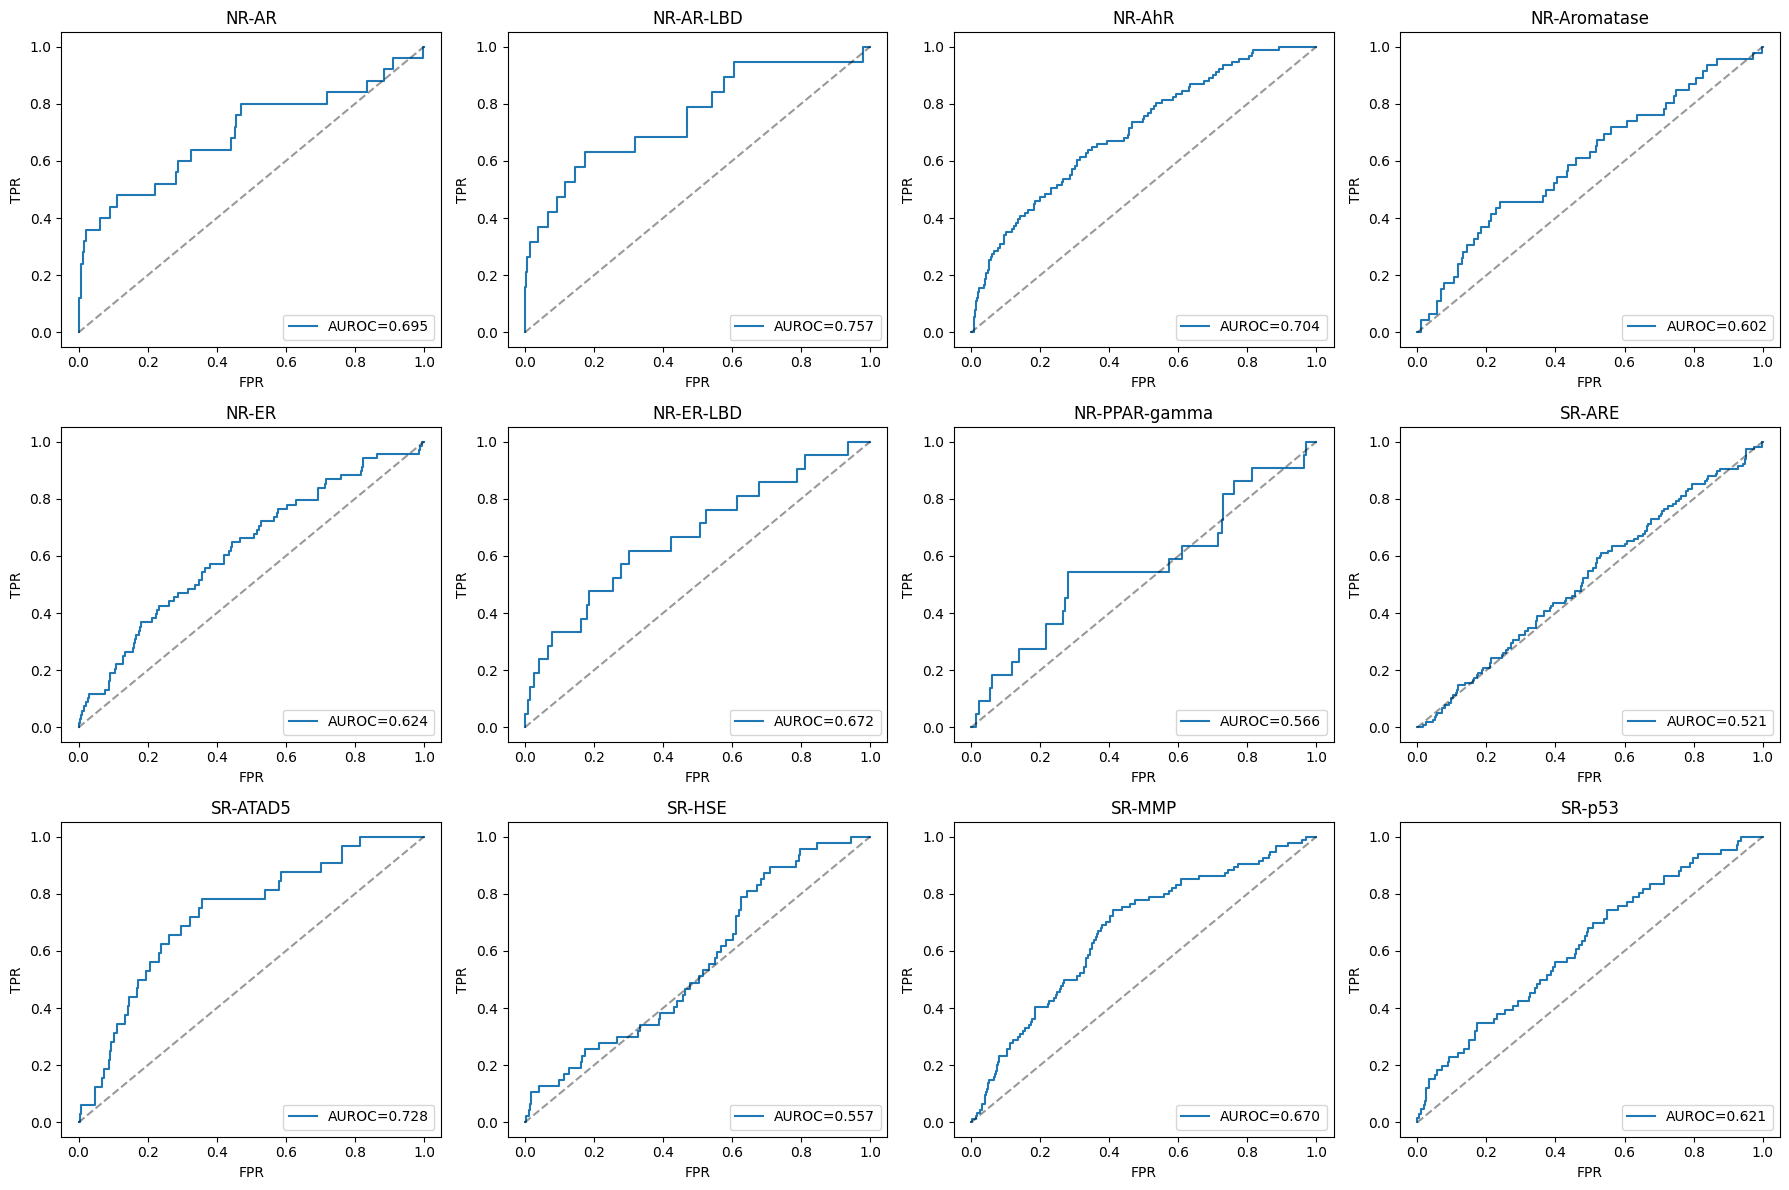

In [24]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

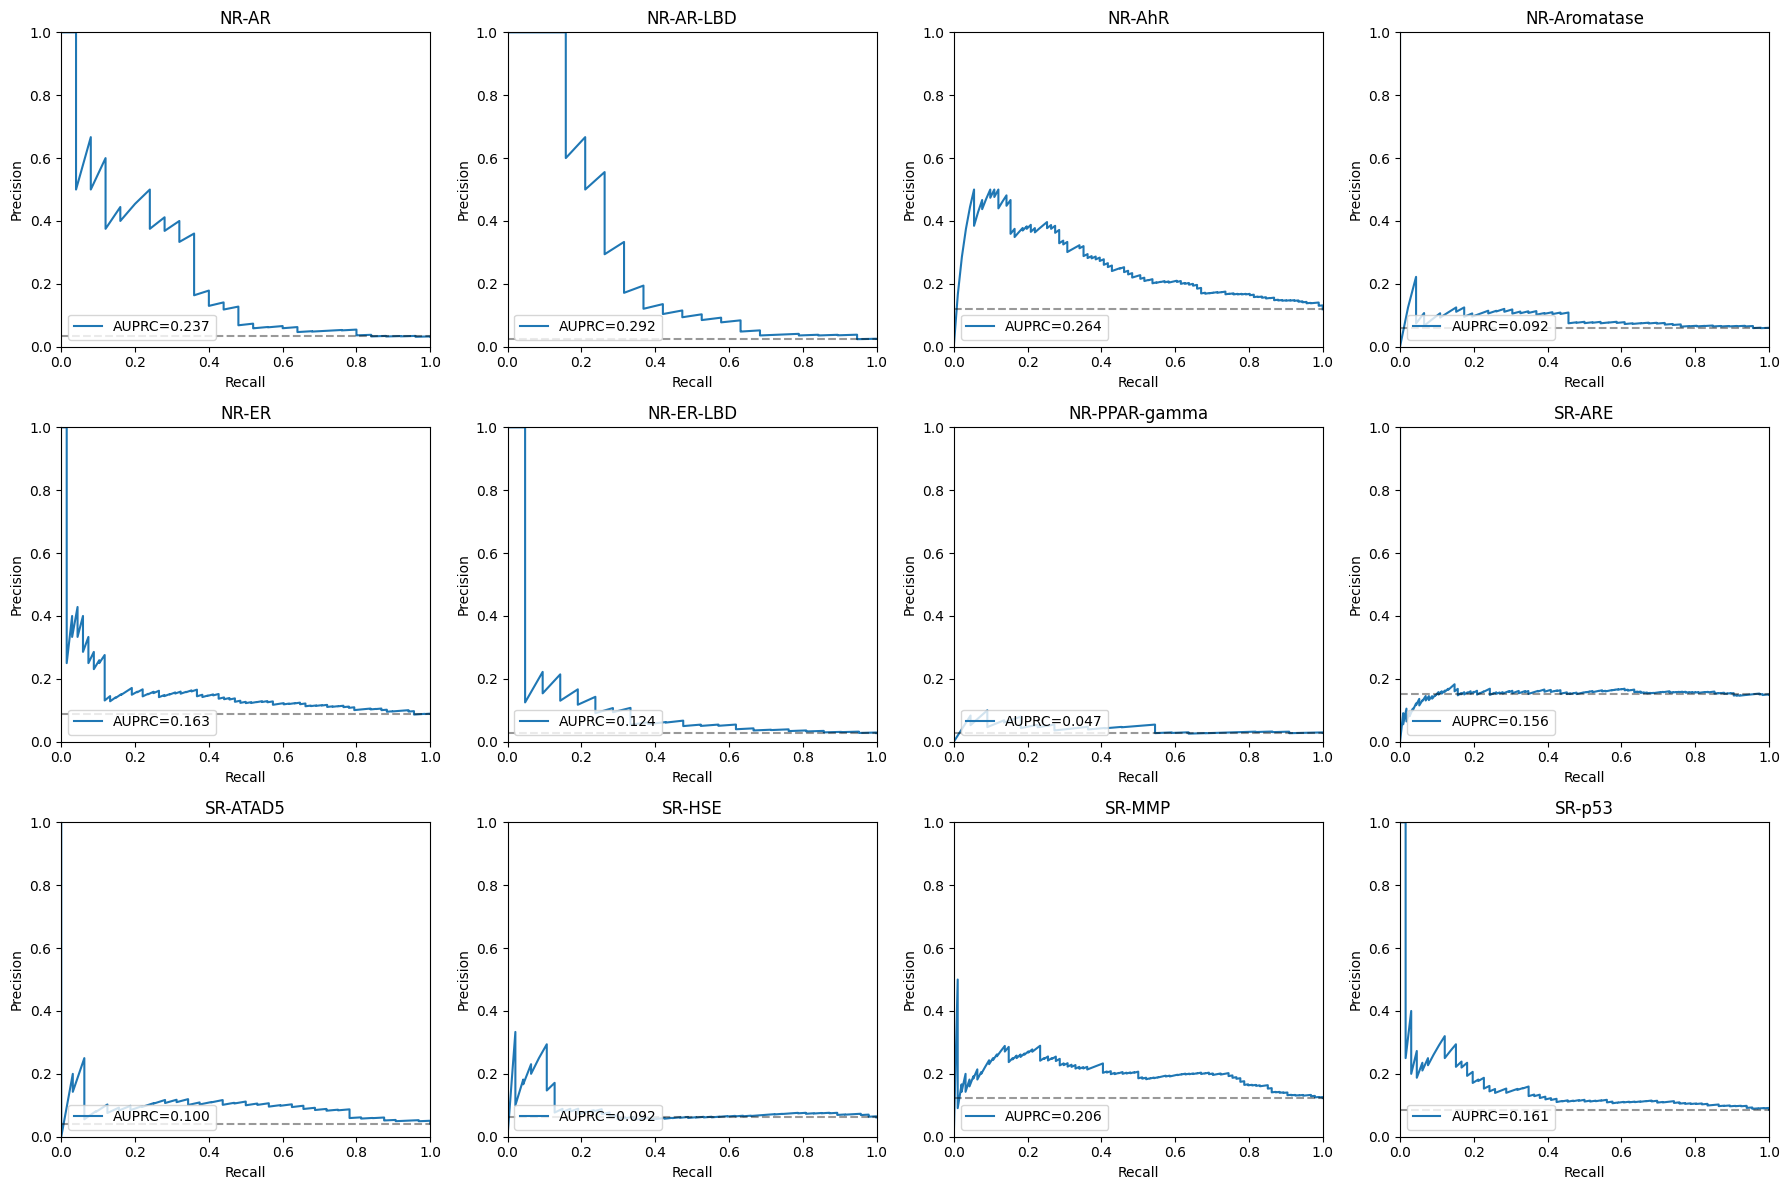

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, label=f"AUPRC={ap:.3f}")
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Tox21 test token accuracy using BEST pretrained checkpoint
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"
best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"

if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

# 1) Load tox21 test SMILES
tox21_test_df = pd.read_csv(TOX21_TEST_PATH)
tox21_test_smiles = tox21_test_df["canonical_smiles"].dropna().astype(str).tolist()
tox21_test_smiles = list(dict.fromkeys(tox21_test_smiles))

# 2) Convert + filter exactly like pretraining pipeline
tox21_test_selfies, tox21_failed = smiles_to_selfies(tox21_test_smiles)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)
tox21_test_x = encode_list(tox21_test_selfies)

# 3) Load best model weights
bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(
    vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM
).to(device)
model_best.load_state_dict(bundle["model_state_dict"])

# 4) Evaluate (same token-accuracy computation path as this notebook)
beta_eval = (
    bundle["history"]["beta"][-1]
    if "history" in bundle and "beta" in bundle["history"]
    else 1.0
)
tox21_metrics = evaluate(model_best, tox21_test_x, beta=beta_eval)

print(f"Best checkpoint: {best_ckpt_path.name}")
print(
    f"Tox21 test SMILES: raw={len(tox21_test_smiles):,} | selfies_ok={len(tox21_test_selfies):,} | failed={tox21_failed:,}"
)
print(
    f"Tox21 test metrics -> "
    f"total={tox21_metrics['total']:.4f}, "
    f"recon_per_token={tox21_metrics['recon_per_token']:.4f}, "
    f"kl={tox21_metrics['kl']:.4f}, "
    f"token_acc={tox21_metrics['token_acc']:.4f}"
)

Best checkpoint: paper_like_selfies_chembl_zinc_seqconv_ce_best.pt
Tox21 test SMILES: raw=783 | selfies_ok=765 | failed=0
Tox21 test metrics -> total=68.5168, recon_per_token=0.9323, kl=29.2259, token_acc=0.7571


# VAE Optimization Exploration

This section focuses on investigating different model aspects to potentially improve performance.

## KL Annealing

Plotting training and validation curve components (reconstruction loss and KL Divergence loss) will help determine if its necessary to incorporate KL annealing. 

Training VAE without KL annealing...
epoch 001 | beta=1.00 | train total=116.4369 | val total=115.1051 | train token acc=0.3888 | val token acc=0.3766 | new best
epoch 002 | beta=1.00 | train total=109.4369 | val total=108.5728 | train token acc=0.4142 | val token acc=0.4052 | new best
epoch 003 | beta=1.00 | train total=103.4327 | val total=98.7128 | train token acc=0.4496 | val token acc=0.4795 | new best
epoch 004 | beta=1.00 | train total=98.0838 | val total=93.6188 | train token acc=0.4701 | val token acc=0.5019 | new best
epoch 005 | beta=1.00 | train total=92.7046 | val total=88.6577 | train token acc=0.4997 | val token acc=0.5339 | new best
epoch 006 | beta=1.00 | train total=88.1487 | val total=88.5869 | train token acc=0.5375 | val token acc=0.5329 | new best
epoch 007 | beta=1.00 | train total=83.1297 | val total=79.6947 | train token acc=0.5824 | val token acc=0.6106 | new best
epoch 008 | beta=1.00 | train total=79.2002 | val total=78.5156 | train token acc=0.6146 | val to

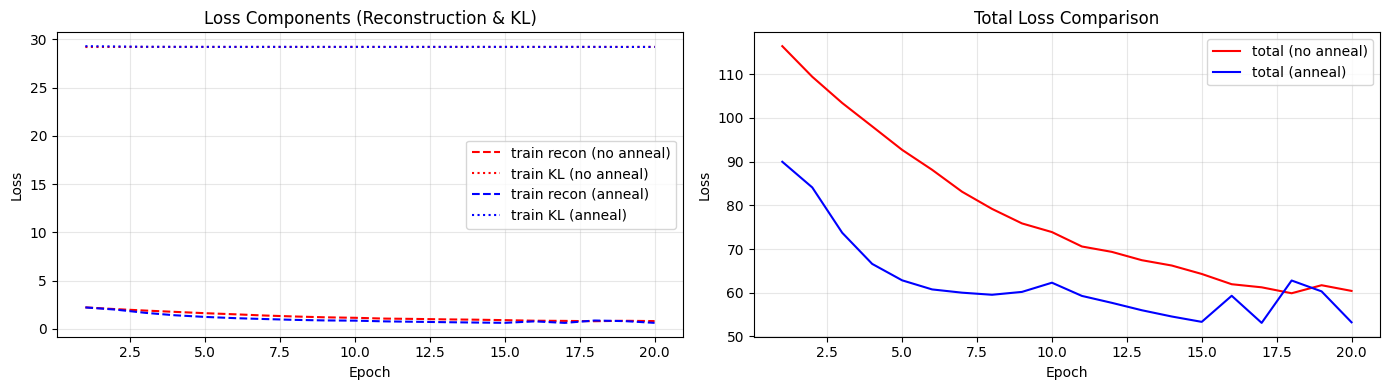

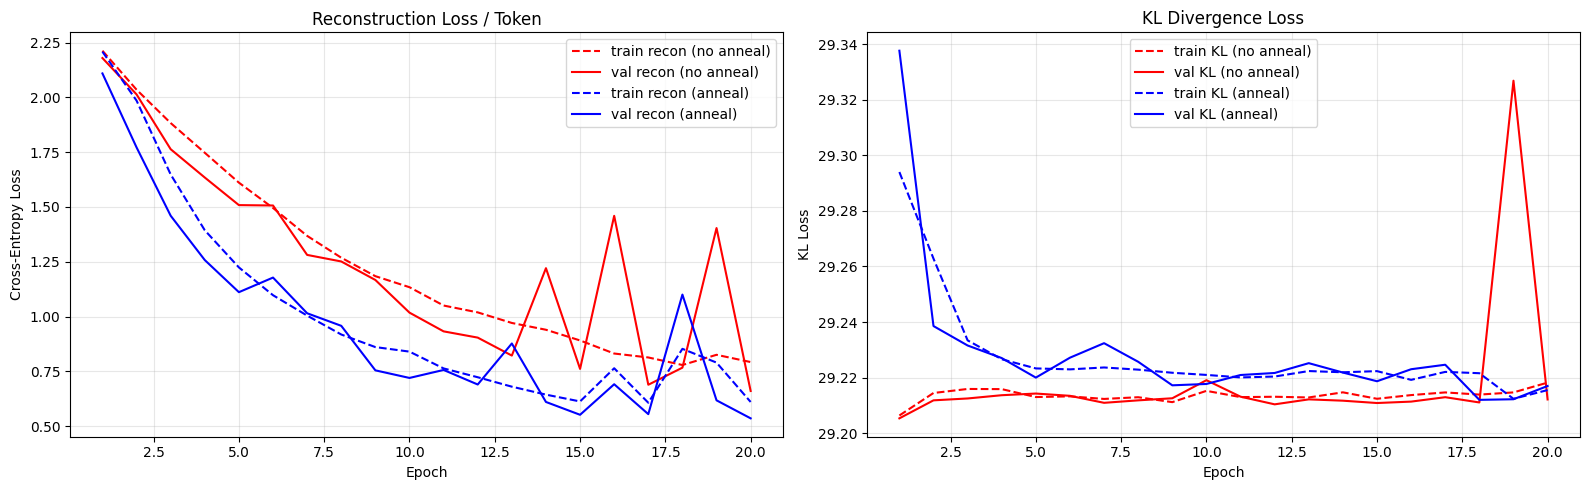

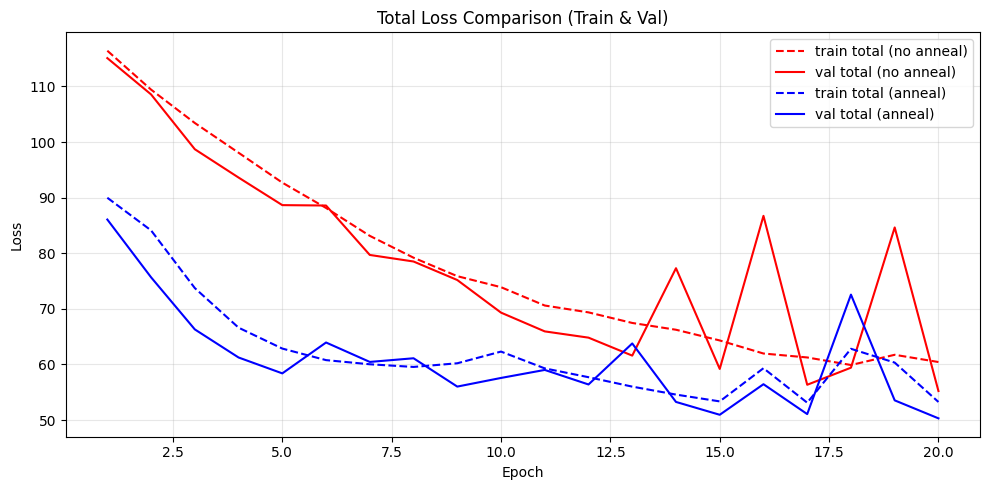

In [12]:
# ==========================
# 1. Extended Training & Evaluation
# ==========================


def train_and_evaluate(
    train_x: np.ndarray,
    val_x: np.ndarray,
    test_x: np.ndarray,
    *,
    use_kl_annealing: bool = True,
    save_dir: Path,
    checkpoint_stem: str,
):
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"Training VAE {'with' if use_kl_annealing else 'without'} KL annealing...")

    # Override KL anneal epochs if disabling annealing
    global KL_ANNEAL_EPOCHS
    kl_anneal_epochs_orig = KL_ANNEAL_EPOCHS
    KL_ANNEAL_EPOCHS = KL_ANNEAL_EPOCHS if use_kl_annealing else 1

    # Train
    model, history, checkpoint_info = train_model(
        train_x,
        val_x,
        checkpoint_dir=save_dir,
        checkpoint_stem=checkpoint_stem,
        save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
    )

    # Restore global
    KL_ANNEAL_EPOCHS = kl_anneal_epochs_orig

    # Evaluate on test
    final_beta = history["beta"][-1]
    test_metrics = evaluate(model, test_x, beta=final_beta)

    # Save legacy checkpoint for compatibility
    ckpt_path = save_dir / f"{checkpoint_stem}.pt"
    torch.save(
        _checkpoint_payload(
            model,
            history,
            epoch=len(history["beta"]),
            best_epoch=checkpoint_info["best_epoch"],
            best_val_total=checkpoint_info["best_val_total"],
            optimizer=None,
            test_metrics=test_metrics,
        ),
        ckpt_path,
    )

    results_df = pd.DataFrame(
        [
            {
                "run_name": checkpoint_stem,
                "n_train": len(train_x),
                "n_val": len(val_x),
                "n_test": len(test_x),
                "final_train_total": history["train_total"][-1],
                "final_val_total": history["val_total"][-1],
                "final_train_token_acc": history["train_token_acc"][-1],
                "final_val_token_acc": history["val_token_acc"][-1],
                "best_epoch": checkpoint_info["best_epoch"],
                "best_val_total": checkpoint_info["best_val_total"],
                "test_total": test_metrics["total"],
                "test_recon_per_token": test_metrics["recon_per_token"],
                "test_kl": test_metrics["kl"],
                "test_token_acc": test_metrics["token_acc"],
                "checkpoint_best": str(save_dir / f"{checkpoint_stem}_best.pt"),
                "checkpoint_last": str(save_dir / f"{checkpoint_stem}_last.pt"),
                "checkpoint_compat": str(ckpt_path),
            }
        ]
    )

    return model, history, results_df


# ==========================
# 2. Run Training: No Annealing & With Annealing
# ==========================

save_dir_no_anneal = CHECKPOINT_DIR / "no_kl_anneal"
save_dir_anneal = CHECKPOINT_DIR / "kl_anneal"

# Training runs
model_no_anneal, history_no_anneal, df_no_anneal = train_and_evaluate(
    train_x,
    val_x,
    test_x,
    use_kl_annealing=False,
    save_dir=save_dir_no_anneal,
    checkpoint_stem="vae_no_kl_anneal",
)

model_anneal, history_anneal, df_anneal = train_and_evaluate(
    train_x,
    val_x,
    test_x,
    use_kl_annealing=True,
    save_dir=save_dir_anneal,
    checkpoint_stem="vae_kl_anneal",
)

# ==========================
# 3. Plotting Loss Components
# ==========================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_no_anneal = np.arange(1, len(history_no_anneal["train_total"]) + 1)
epochs_anneal = np.arange(1, len(history_anneal["train_total"]) + 1)

# ---- Loss components (Reconstruction & KL) ----
axes[0].plot(
    epochs_no_anneal,
    history_no_anneal["train_recon_per_token"],
    "r--",
    label="train recon (no anneal)",
)
axes[0].plot(
    epochs_no_anneal, history_no_anneal["train_kl"], "r:", label="train KL (no anneal)"
)
axes[0].plot(
    epochs_anneal,
    history_anneal["train_recon_per_token"],
    "b--",
    label="train recon (anneal)",
)
axes[0].plot(epochs_anneal, history_anneal["train_kl"], "b:", label="train KL (anneal)")
axes[0].set_title("Loss Components (Reconstruction & KL)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ---- Total loss curves ----
axes[1].plot(
    epochs_no_anneal, history_no_anneal["train_total"], "r-", label="total (no anneal)"
)
axes[1].plot(epochs_anneal, history_anneal["train_total"], "b-", label="total (anneal)")
axes[1].set_title("Total Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================
# 4. Plot Train & Validation: Loss Components with Annealing Comparison
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs_no_anneal = np.arange(1, len(history_no_anneal["train_total"]) + 1)
epochs_anneal = np.arange(1, len(history_anneal["train_total"]) + 1)

# ---- Left: Reconstruction Loss (train & val) ----
axes[0].plot(
    epochs_no_anneal,
    history_no_anneal["train_recon_per_token"],
    "r--",
    label="train recon (no anneal)",
)
axes[0].plot(
    epochs_no_anneal,
    history_no_anneal["val_recon_per_token"],
    "r-",
    label="val recon (no anneal)",
)
axes[0].plot(
    epochs_anneal,
    history_anneal["train_recon_per_token"],
    "b--",
    label="train recon (anneal)",
)
axes[0].plot(
    epochs_anneal,
    history_anneal["val_recon_per_token"],
    "b-",
    label="val recon (anneal)",
)
axes[0].set_title("Reconstruction Loss / Token")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ---- Right: KL Divergence Loss (train & val) ----
axes[1].plot(
    epochs_no_anneal, history_no_anneal["train_kl"], "r--", label="train KL (no anneal)"
)
axes[1].plot(
    epochs_no_anneal, history_no_anneal["val_kl"], "r-", label="val KL (no anneal)"
)
axes[1].plot(
    epochs_anneal, history_anneal["train_kl"], "b--", label="train KL (anneal)"
)
axes[1].plot(epochs_anneal, history_anneal["val_kl"], "b-", label="val KL (anneal)")
axes[1].set_title("KL Divergence Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================
# 5. Total Loss: Train & Val, Anneal vs No Anneal
# ==========================

fig, ax = plt.subplots(figsize=(10, 5))

epochs_no_anneal = np.arange(1, len(history_no_anneal["train_total"]) + 1)
epochs_anneal = np.arange(1, len(history_anneal["train_total"]) + 1)

# ---- Total loss curves ----
ax.plot(
    epochs_no_anneal,
    history_no_anneal["train_total"],
    "r--",
    label="train total (no anneal)",
)
ax.plot(
    epochs_no_anneal,
    history_no_anneal["val_total"],
    "r-",
    label="val total (no anneal)",
)

ax.plot(
    epochs_anneal, history_anneal["train_total"], "b--", label="train total (anneal)"
)
ax.plot(epochs_anneal, history_anneal["val_total"], "b-", label="val total (anneal)")

ax.set_title("Total Loss Comparison (Train & Val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

After training for 20 epochs and plotting the individual loss components for both training runs, the current model architecture and hyperparameters show the KL Divergence Loss term does not collapse (go to 0) with annealing or without annealing. Model performance with and without annealing shows no significant difference. Slightly more stable curves and convergence can be noted when training with KL annealing. Hence, KL Annealing is not required in this scenario but can be used for quicker convergence and stability.

Free Bits

Plotting the individual loss components for the training and validation sets for two runs - one with free-bits and the other without free-bits. Both runs will move forward with KL annealing.


Training VAE without free-bits...
epoch 001 | beta=0.10 | train total=87.4618 | val total=83.9355 | train token acc=0.3915 | val token acc=0.4061 | new best
epoch 002 | beta=0.20 | train total=76.1574 | val total=63.9805 | train token acc=0.4347 | val token acc=0.5045 | new best
epoch 003 | beta=0.30 | train total=56.2518 | val total=48.9538 | train token acc=0.5685 | val token acc=0.6296 | new best
epoch 004 | beta=0.40 | train total=45.5095 | val total=40.3738 | train token acc=0.6568 | val token acc=0.6978 | new best
epoch 005 | beta=0.50 | train total=38.7559 | val total=36.2781 | train token acc=0.7086 | val token acc=0.7257 | new best
epoch 006 | beta=0.60 | train total=34.1885 | val total=31.3410 | train token acc=0.7411 | val token acc=0.7607 | new best
epoch 007 | beta=0.70 | train total=30.8673 | val total=29.9237 | train token acc=0.7638 | val token acc=0.7698 | new best
epoch 008 | beta=0.80 | train total=28.0708 | val total=26.1227 | train token acc=0.7829 | val token acc

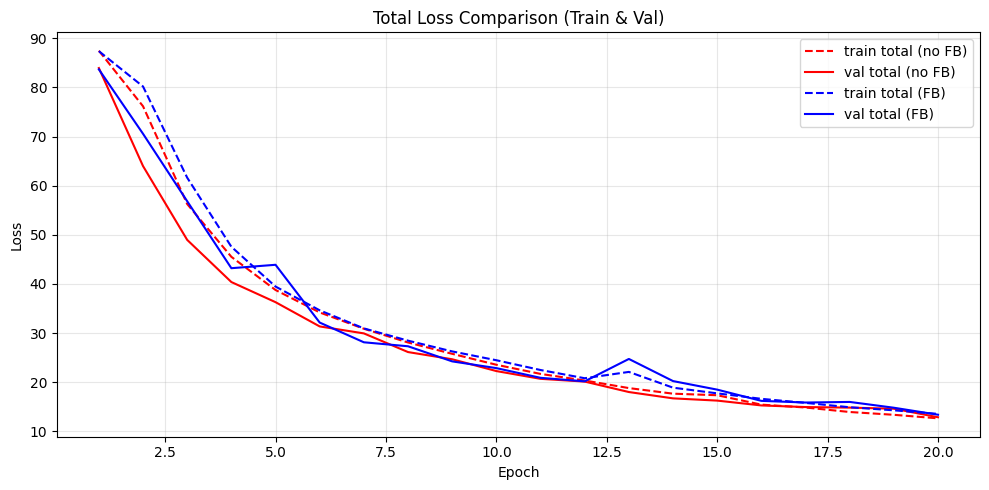

In [14]:
# ==========================
# Free-Bits Comparative Training
# ==========================


def train_and_evaluate_freebits(
    train_x,
    val_x,
    test_x,
    *,
    use_free_bits: bool,
    num_epochs: int = 20,
    save_dir: Path,
    checkpoint_stem: str,
):
    global FREE_BITS_NATS  # override global free bits for this run

    # Backup old value
    old_free_bits = FREE_BITS_NATS

    # Set free-bits for this run
    FREE_BITS_NATS = 0.0 if not use_free_bits else old_free_bits

    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nTraining VAE {'with' if use_free_bits else 'without'} free-bits...")

    model, history, checkpoint_info = train_model(
        train_x,
        val_x,
        checkpoint_dir=save_dir,
        checkpoint_stem=checkpoint_stem,
        save_epoch_checkpoints=True,
        num_epochs=num_epochs,
    )

    final_beta = history["beta"][-1]
    test_metrics = evaluate(model, test_x, beta=final_beta)

    # Save legacy checkpoint
    ckpt_path = save_dir / f"{checkpoint_stem}.pt"
    torch.save(
        _checkpoint_payload(
            model,
            history,
            epoch=len(history["beta"]),
            best_epoch=checkpoint_info["best_epoch"],
            best_val_total=checkpoint_info["best_val_total"],
            optimizer=None,
            test_metrics=test_metrics,
        ),
        ckpt_path,
    )

    results_df = pd.DataFrame(
        [
            {
                "run_name": checkpoint_stem,
                "n_train": len(train_x),
                "n_val": len(val_x),
                "n_test": len(test_x),
                "final_train_total": history["train_total"][-1],
                "final_val_total": history["val_total"][-1],
                "final_train_token_acc": history["train_token_acc"][-1],
                "final_val_token_acc": history["val_token_acc"][-1],
                "best_epoch": checkpoint_info["best_epoch"],
                "best_val_total": checkpoint_info["best_val_total"],
                "test_total": test_metrics["total"],
                "test_recon_per_token": test_metrics["recon_per_token"],
                "test_kl": test_metrics["kl"],
                "test_token_acc": test_metrics["token_acc"],
                "checkpoint_best": str(save_dir / f"{checkpoint_stem}_best.pt"),
                "checkpoint_last": str(save_dir / f"{checkpoint_stem}_last.pt"),
                "checkpoint_compat": str(ckpt_path),
            }
        ]
    )

    # Restore old FREE_BITS_NATS value
    FREE_BITS_NATS = old_free_bits

    return model, history, results_df


# ==========================
# Train both runs
# ==========================
save_dir_no_fb = CHECKPOINT_DIR / "no_free_bits"
save_dir_fb = CHECKPOINT_DIR / "with_free_bits"

# 1️⃣ Train without free-bits (new)
model_no_fb, history_no_fb, df_no_fb = train_and_evaluate_freebits(
    train_x,
    val_x,
    test_x,
    use_free_bits=False,
    num_epochs=EPOCHS,  # uses your global EPOCHS variable
    save_dir=save_dir_no_fb,
    checkpoint_stem="vae_no_free_bits",
)

# 2️⃣ Train with free-bits (regular)
model_fb, history_fb, df_fb = train_and_evaluate_freebits(
    train_x,
    val_x,
    test_x,
    use_free_bits=True,
    num_epochs=EPOCHS,  # uses your global EPOCHS variable
    save_dir=save_dir_fb,
    checkpoint_stem="vae_with_free_bits",
)

# ==========================
# Plot Total Loss Comparison
# ==========================
fig, ax = plt.subplots(figsize=(10, 5))

epochs = np.arange(1, EPOCHS + 1)  # x-axis for both runs

ax.plot(epochs, history_no_fb["train_total"], "r--", label="train total (no FB)")
ax.plot(epochs, history_no_fb["val_total"], "r-", label="val total (no FB)")

ax.plot(epochs, history_fb["train_total"], "b--", label="train total (FB)")
ax.plot(epochs, history_fb["val_total"], "b-", label="val total (FB)")

ax.set_title("Total Loss Comparison (Train & Val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Learning Rate


Run: lr0.002_decay0.75 | lr=0.002 | decay=0.75
epoch 001 | lr=0.002000 | train total=85.5560 | val total=78.7300
epoch 002 | lr=0.002000 | train total=72.7468 | val total=65.2586
epoch 003 | lr=0.002000 | train total=60.1415 | val total=53.0093
epoch 004 | lr=0.002000 | train total=51.8085 | val total=46.9901
epoch 005 | lr=0.002000 | train total=46.5966 | val total=42.6412
epoch 006 | lr=0.002000 | train total=43.2072 | val total=41.4149
epoch 007 | lr=0.002000 | train total=40.3822 | val total=35.5438
epoch 008 | lr=0.002000 | train total=37.8705 | val total=33.9046
epoch 009 | lr=0.002000 | train total=40.2268 | val total=34.5040
epoch 010 | lr=0.002000 | train total=37.6075 | val total=33.7561
epoch 011 | lr=0.002000 | train total=49.0084 | val total=45.4036
epoch 012 | lr=0.002000 | train total=41.3863 | val total=37.1268
epoch 013 | lr=0.002000 | train total=35.3868 | val total=31.6594
epoch 014 | lr=0.002000 | train total=32.4065 | val total=29.3852
epoch 015 | lr=0.002000 | tr

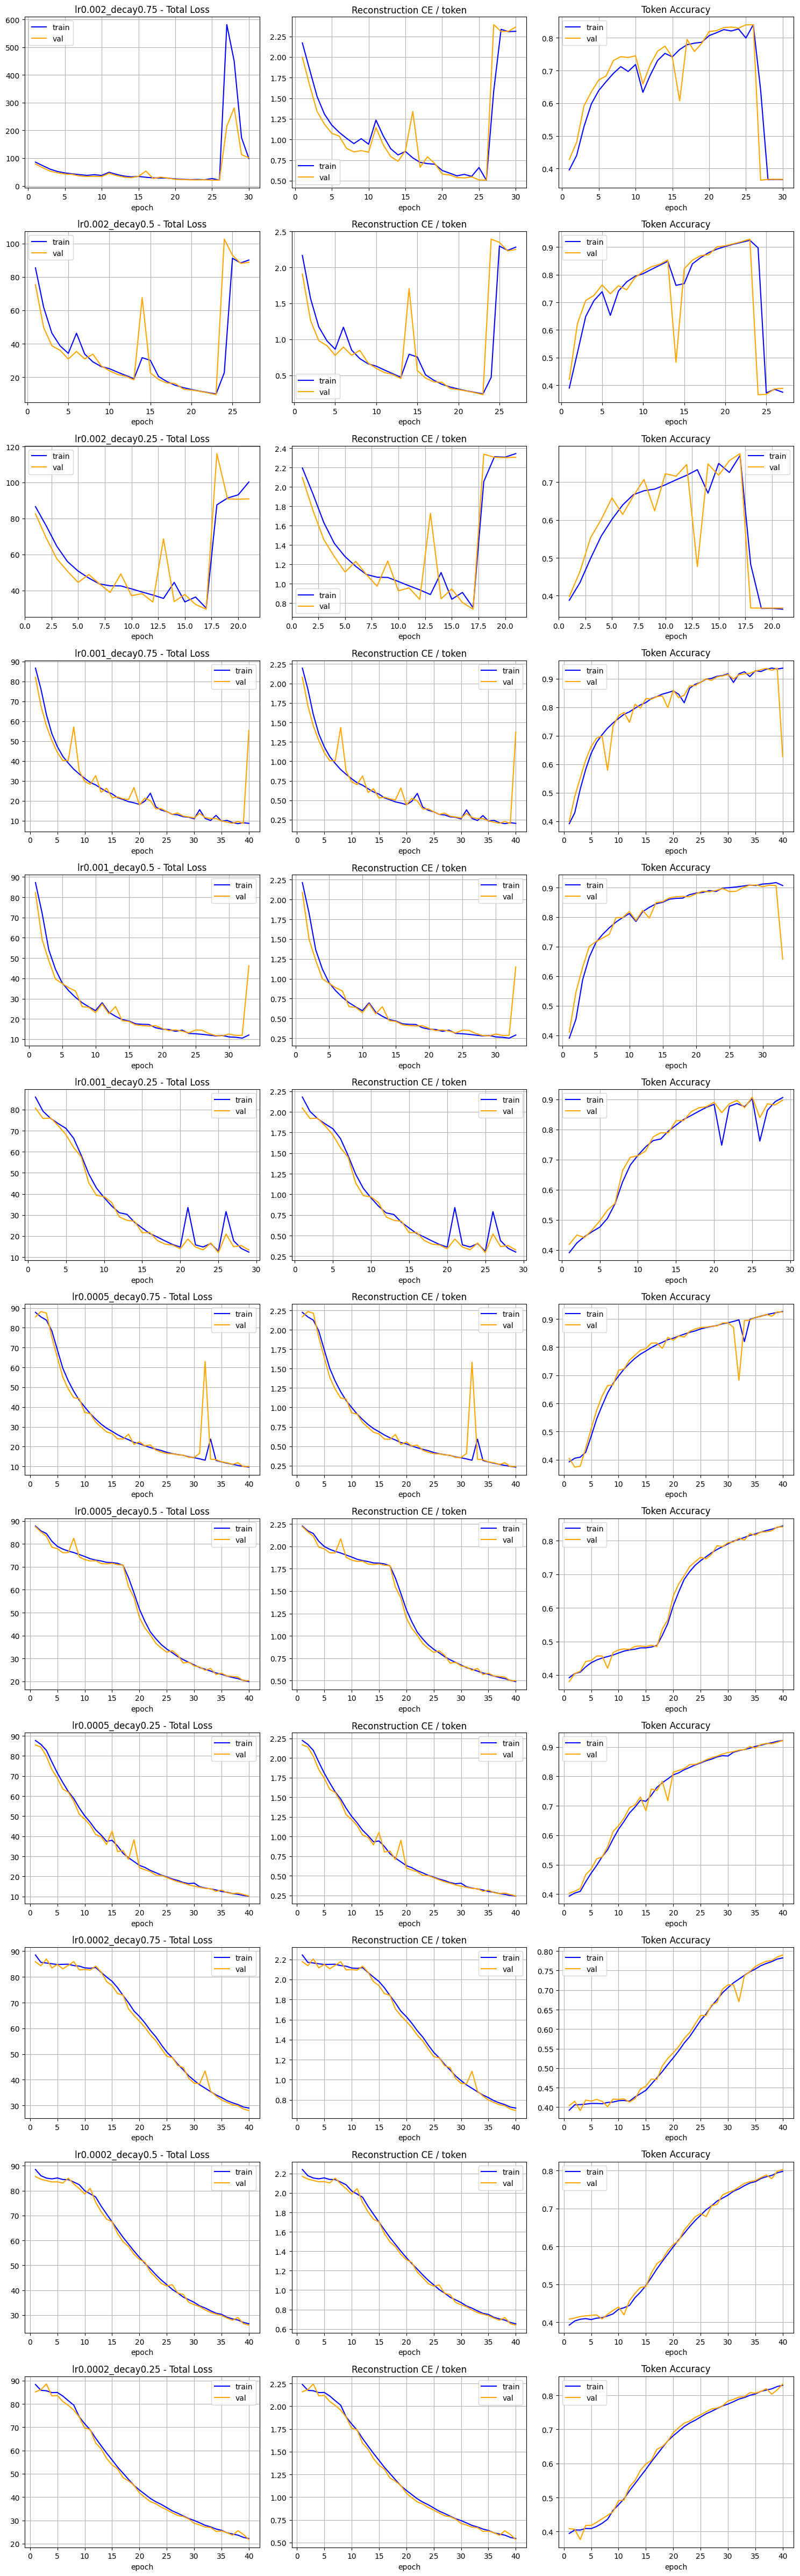

In [15]:
def train_lr_experiment(
    train_x,
    val_x,
    test_x,
    *,
    lr: float,
    decay_factor: float,
    patience: int = 4,
    num_epochs: int = 40,
    run_name: str,
):
    print(f"\nRun: {run_name} | lr={lr} | decay={decay_factor}")

    model = PaperLikeSelfiesVAE(
        vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=decay_factor,
        patience=patience,
        min_lr=1e-6,
    )

    train_loader = make_loader(train_x, BATCH_SIZE, shuffle=True)

    history = {
        "train_total": [],
        "val_total": [],
        "train_recon_per_token": [],
        "val_recon_per_token": [],
        "train_token_acc": [],
        "val_token_acc": [],
    }

    best_val = float("inf")
    epochs_no_improve = 0

    for ep in range(1, num_epochs + 1):
        beta = kl_beta(ep, KL_ANNEAL_EPOCHS)

        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, beta=beta)
        val_metrics = evaluate(model, val_x, beta=beta)

        # Store history
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])

        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])

        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])

        # Scheduler step
        scheduler.step(val_metrics["total"])

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"epoch {ep:03d} | lr={current_lr:.6f} | "
            f"train total={train_metrics['total']:.4f} | val total={val_metrics['total']:.4f}"
        )

        # 🔥 Early stopping
        if val_metrics["total"] < best_val:
            best_val = val_metrics["total"]
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {ep}")
            break

    return model, history


learning_rates = [2e-3, 1e-3, 5e-4, 2e-4]  # added higher LR
decay_factors = [0.75, 0.5, 0.25]

results = []
histories = {}

for lr in learning_rates:
    for decay in decay_factors:
        run_name = f"lr{lr}_decay{decay}"

        model, history = train_lr_experiment(
            train_x,
            val_x,
            test_x,
            lr=lr,
            decay_factor=decay,
            patience=4,
            num_epochs=40,
            run_name=run_name,
        )

        histories[run_name] = history

        results.append(
            {
                "run": run_name,
                "lr": lr,
                "decay": decay,
                "final_train_total": history["train_total"][-1],
                "final_val_total": history["val_total"][-1],
                "final_train_acc": history["train_token_acc"][-1],
                "final_val_acc": history["val_token_acc"][-1],
                "final_train_recon": history["train_recon_per_token"][-1],
                "final_val_recon": history["val_recon_per_token"][-1],
            }
        )

results_df = pd.DataFrame(results)
results_df

n_rows = len(histories)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))

for i, (run_name, history) in enumerate(histories.items()):
    epochs = np.arange(1, len(history["train_total"]) + 1)

    # ---- Total loss ----
    axes[i, 0].plot(epochs, history["train_total"], color="blue", label="train")
    axes[i, 0].plot(epochs, history["val_total"], color="orange", label="val")
    axes[i, 0].set_title(f"{run_name} - Total Loss")
    axes[i, 0].set_xlabel("epoch")
    axes[i, 0].grid(True)

    # ---- Reconstruction ----
    axes[i, 1].plot(
        epochs, history["train_recon_per_token"], color="blue", label="train"
    )
    axes[i, 1].plot(epochs, history["val_recon_per_token"], color="orange", label="val")
    axes[i, 1].set_title("Reconstruction CE / token")
    axes[i, 1].set_xlabel("epoch")
    axes[i, 1].grid(True)

    # ---- Token Accuracy ----
    axes[i, 2].plot(epochs, history["train_token_acc"], color="blue", label="train")
    axes[i, 2].plot(epochs, history["val_token_acc"], color="orange", label="val")
    axes[i, 2].set_title("Token Accuracy")
    axes[i, 2].set_xlabel("epoch")
    axes[i, 2].grid(True)

    for j in range(3):
        axes[i, j].legend()

plt.tight_layout()
plt.show()

Learning rate analysis shows the best learning rate is 0.001 with a decay on plateau of 0.5 and 0.25. 